In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
master = pd.read_csv(
    "../clean_data/master_energy_dataset.csv"
)

master.head()

,Timestamp,Demand_MW,Wind_MW,Solar_MW,Renewable_MW,Temperature_C,WindSpeed,CloudCover,Price_p_kWh,Hour,Month,Weekend
0,2026-03-01 11:00:00,25771.0,3958.5,4110.0,8068.5,10.8,23.9,100,-0.4140,11,3,1
1,2026-03-01 12:00:00,26979.5,4077.0,4002.5,8079.5,10.6,18.5,100,0.0745,12,3,1
2,2026-03-01 13:00:00,27497.0,4112.0,3801.5,7913.5,11.3,24.6,98,0.6015,13,3,1
3,2026-03-01 14:00:00,27420.5,4160.0,3403.5,7563.5,11.9,25.8,71,1.9565,14,3,1
4,2026-03-01 15:00:00,28286.0,4209.0,2189.5,6398.5,12.2,21.5,89,6.4990,15,3,1


In [4]:
master.shape
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2125 entries, 0 to 2124
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Timestamp      2125 non-null   object 
 1   Demand_MW      2124 non-null   float64
 2   Wind_MW        2124 non-null   float64
 3   Solar_MW       2124 non-null   float64
 4   Renewable_MW   2124 non-null   float64
 5   Temperature_C  2125 non-null   float64
 6   WindSpeed      2125 non-null   float64
 7   CloudCover     2125 non-null   int64  
 8   Price_p_kWh    1873 non-null   float64
 9   Hour           2125 non-null   int64  
 10  Month          2125 non-null   int64  
 11  Weekend        2125 non-null   int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 199.3+ KB


In [5]:
master.duplicated().sum()

np.int64(0)

No duplicate records were found.

Exploratory Data Analysis

<Axes: >

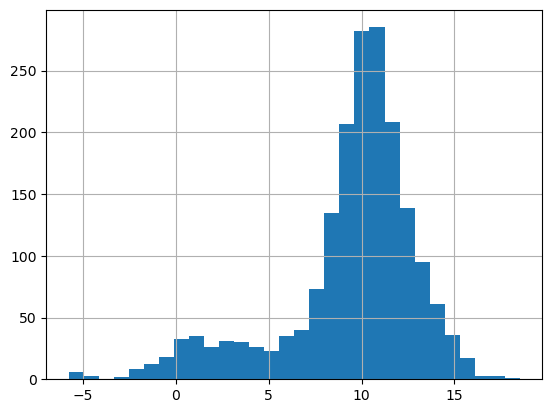

In [ ]:
# Price Distribution
master["Price_p_kWh"].hist(
    bins=30
)

<!-- Price Over Time -->
plt.figure(figsize=(12,5))

plt.plot(
    pd.to_datetime(master["Timestamp"]),
    master["Price_p_kWh"]
)

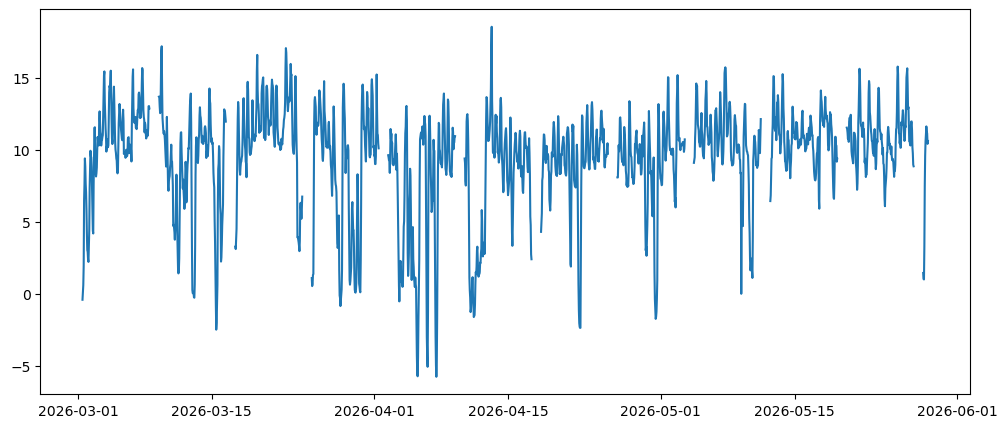

In [7]:
plt.figure(figsize=(12,5))

plt.plot(
    pd.to_datetime(master["Timestamp"]),
    master["Price_p_kWh"]
)

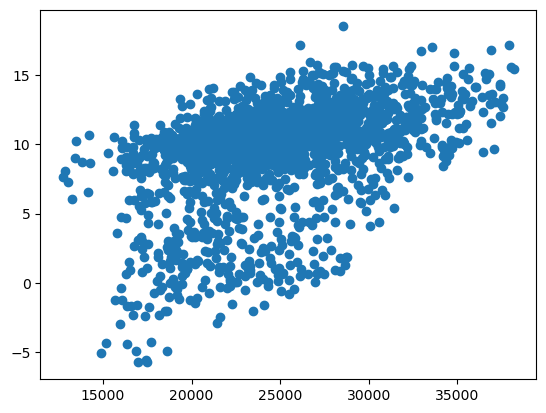

In [8]:
# Demand vs Price
plt.scatter(
    master["Demand_MW"],
    master["Price_p_kWh"]
)

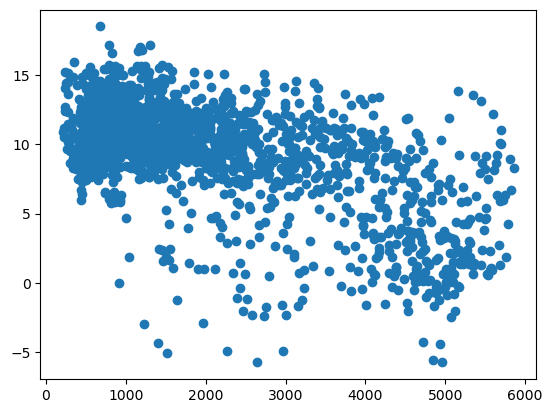

In [10]:
# Wind vs Price
plt.scatter(
    master["Wind_MW"],
    master["Price_p_kWh"]
)

In [11]:
corr = (
    master
    .corr(numeric_only=True)
)

corr["Price_p_kWh"] \
    .sort_values(
        ascending=False
    )

Price_p_kWh      1.000000
Demand_MW        0.450216
Hour             0.136771
Month            0.086829
Temperature_C    0.008390
CloudCover      -0.022953
Weekend         -0.171582
Solar_MW        -0.301152
Renewable_MW    -0.484386
WindSpeed       -0.528563
Wind_MW         -0.591563
Name: Price_p_kWh, dtype: float64

Key observations:

- Demand positively correlates with price.
- Wind generation negatively correlates with price.
- Renewable generation generally reduces electricity prices.

In [19]:
features = [
    "Demand_MW",
    "Wind_MW",
    "Solar_MW",
    "Temperature_C",
    "WindSpeed",
    "CloudCover",
    "Hour",
    "Month",
    "Weekend"
]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


NameError: name 'train_test_split' is not defined

In [16]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

ValueError: Input y contains NaN.